# 1. 芯片初始化操作

In [1]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
import numpy as np

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_v

In [87]:
chip=CHIP(PS(host="192.168.1.11", port = 7, delay=0.3, debug=0),init=True)
chip.set_device_cfg(deviceType=0,IsNew32=True)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=50,adc_last_gap=10)
chip.clk_manager.set_cyc(delay1=20,delay2=20,delay3=20)

# pkts=Packet()
# pkts.append_cmdlist([CMD(DEVICE_CFG,command_data=CmdData(1)),],mode=1)
# chip.ps.send_packets(pkts)

Connected to 192.168.1.11:7
local ip: 192.168.1.15 local port: 57339


# 2. 读器件

## 2.1 常规读操作

In [252]:
chip.set_op_mode(read=True,from_row=True)                                   # 设置为读模式, 并且是从行读
chip.set_dac_read_V(0.1,tg=5)                                               # 设置读电压, 会根据device的自动配置对应的DAC通道
chip.set_tia_gain(1)                                                        # 设置TIA的增益
print(chip.get_setting_info())

操作模式: read	器件: ReRAM	读电压: 0.1v	从行\列给电压: 行	TIA增益: 1


In [253]:
voltage = chip.read(row_index=[100],col_index=[100],row_value=None,col_value=None,check_tia=True)
print(f"电压:{voltage}v")
cond = chip.voltage_to_cond(voltage=voltage)
print(f"电导:{cond}us")
resistance = chip.voltage_to_resistance(voltage=voltage)
print(f"电阻:{voltage}kΩ")

配置 2 262144
配置 2 262144
电压:[0.16495254]v
电导:[1369.10529139]us
电阻:[0.16495254]kΩ


## 2.2 自定义配置latch读操作

In [254]:
# # 电阻版测试需要配置最后一个DAC的通道电压
# v=0
# chip.clear_dac_v()
# chip.dac.set_voltage(1,dac_num=0,dac_channel=0)             # ROW_Va电压
# chip.dac.set_voltage(1,dac_num=0,dac_channel=1)             # ROW_Va电压
# chip.dac.set_voltage(1,dac_num=0,dac_channel=2)             # ROW_Va电压
# chip.dac.set_voltage(1,dac_num=0,dac_channel=3)             # ROW_Va电压

# chip.dac.set_voltage(1,dac_num=0,dac_channel=4)             # COL_Va电压
# chip.dac.set_voltage(1,dac_num=0,dac_channel=5)             # COL_Va电压
# chip.dac.set_voltage(1,dac_num=0,dac_channel=6)             # COL_Va电压
# chip.dac.set_voltage(1,dac_num=0,dac_channel=7)             # COL_Va电压

# chip.dac.set_voltage(1,dac_num=1,dac_channel=0)             # ROW_Vc
# chip.dac.set_voltage(1,dac_num=1,dac_channel=1)             # COL_Vc     
# chip.dac.set_voltage(1,dac_num=1,dac_channel=2)             # GL
# chip.dac.set_voltage(1,dac_num=1,dac_channel=3)             # GR

# chip.dac.set_voltage(1,dac_num=1,dac_channel=4)             # ROW_Vc
# chip.dac.set_voltage(1,dac_num=1,dac_channel=5)             # COL_Vc     
# chip.dac.set_voltage(1,dac_num=1,dac_channel=6)             # GL
# chip.dac.set_voltage(1,dac_num=1,dac_channel=7)             # GR

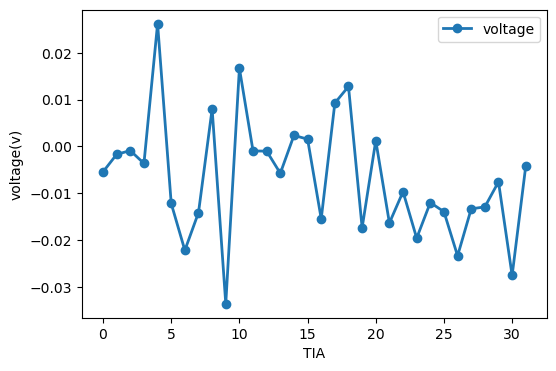

In [255]:
chip.set_tia_gain(0)
chip.set_cim_reset()
chip.generate_read_pulse()
voltage = chip.get_tia_out([k for k in range(32)])
plot_v(v= voltage,figsize=(6,4))

In [236]:
chip.send_cmd(cmd = [CMD(CIM_EN,command_data=CmdData(1))],mode=1)

配置 1 0xffffffff
配置 2 0xffffffff
配置 4 0xffffffff
配置 8 0xffffffff
配置 16 0xffffffff
配置 32 0xffffffff
配置 64 0xffffffff
配置 128 0xffffffff


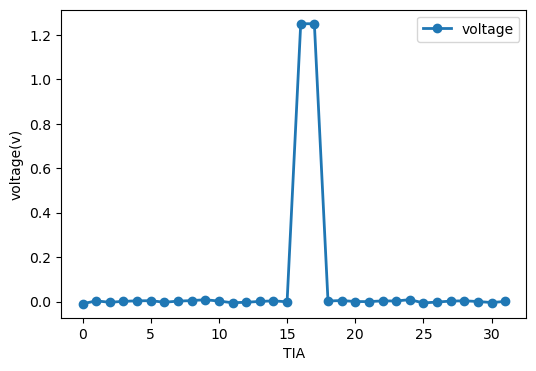

19


In [249]:
chip.set_op_mode(read=True,from_row=True)
chip.set_dac_read_V(0.1)
chip.set_tia_gain(3)

chip.clk_manager.set_cyc(delay1=20,delay2=20,delay3=20)
col = 60
# 先需要reset所有的latch
chip.set_cim_reset()

# 选任意行配ltach
chip.set_latch([i for i in range(256)],row=True,value=None)
# 选任意行bank配32bit值
# chip.set_bank([i for i in range(8)],row=True,value=0xFFFF_FFFF)


# # 配置列bank
# chip.set_latch([col],row=False,value=None)
# chip.set_latch([i for i in range(256)],row=False)
chip.set_bank([0],row=False,value=0xFFFF)

# 产生读脉冲, 并读出tia值
chip.generate_read_pulse()
voltage = chip.get_tia_out([k for k in range(32)])
plot_v(v= voltage,figsize=(6,4))
tia = chip.setting.TIA_index_map(col)
print(tia)

# plot_v(v= voltage,figsize=(6,4))

# 3. 写器件

## 3.1 常规写操作

In [258]:
chip.set_op_mode(read=False,from_row=True)                                  # 设置为写模式, 并且是从行写
chip.set_dac_write_V(0.1)                                                   # 设置为写模式, 并且是从行写
chip.set_pulse_width(0.1)                                                   # 设置写脉冲宽度
print(chip.get_setting_info())

操作模式: write	器件: ReRAM	写电压: 0.1v	从行\列给电压: 行	脉宽: 10000000


In [259]:
chip.write_one(row_index=0,col_index=0)

配置 1 1
配置 1 1


## 3.2 自定义配置行列写操作

In [260]:
chip.set_op_mode(read=False,from_row=True)                                  # 设置为写模式, 并且是从行写
chip.set_dac_write_V(0.1)                                                   # 设置为写模式, 并且是从行写
chip.set_pulse_width(0.1)                                                   # 设置写脉冲宽度
print(chip.get_setting_info())

操作模式: write	器件: ReRAM	写电压: 0.1v	从行\列给电压: 行	脉宽: 10000000


In [261]:
# 先需要reset所有的latch
chip.set_cim_reset()

# 配置行bank
chip.set_latch([2,4,253,255],row=True,value=None)
chip.set_bank([i for i in range(8)],row=True,value=0xFFFF_FFFF)

# 配置列bank
chip.set_latch([2,4,1,3],row=False,value=None)
chip.set_bank([i for i in range(8)],row=False,value=0xFFFF_FFFF)

# 产生写配置
chip.generate_write_pulse()

配置 1 6
配置 128 3221225472
配置 1 6
配置 16 3


# 3. 测试

## 3.1 测试选通对不对

In [262]:
chip.set_op_mode(read=True,from_row=True)                                   # 设置为读模式, 并且是从行读
chip.set_dac_read_V(0.1,tg=5)                                               # 设置读电压, 会根据device的自动配置对应的DAC通道
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)        # 设置TIA增益使用的电阻大小
chip.set_tia_gain(1)                                                        # 设置TIA的增益
print(chip.get_setting_info())

操作模式: read	器件: ReRAM	读电压: 0.1v	从行\列给电压: 行	TIA增益: 1


In [126]:
# 0或1 ：串行读写32个寄存器的使能
chip.send_cmd(cmd = [CMD(CIM_EN,command_data=CmdData(1))],mode=1)

In [264]:
def is_correct_value(voltage,threshold,tia_num):
    for key,value in enumerate(voltage):
        if value>=threshold:
            if key in tia_num:
                pass
            else:
                print(f"这路TIA不应该有值:tia={key},value={value},threshold={threshold}")
                return False
        else:
            if key not in tia_num:
                pass
            else:
                print(f"这路TIA应该有值:tia={key},value={value},threshold={threshold}")
                return False
    return True

第0, 1位设置为1 [-7.24814600e-03  2.21259194e-03 -2.51777703e-03  8.39259011e-04
  7.47703482e-03  2.55592517e-03 -4.19629505e-04  3.58592486e-03
  6.52333140e-03  7.74407178e-03  4.00555437e-03 -3.31888791e-03
  5.34073916e-04  2.02185125e-03  4.31073946e-03  7.62962737e-05]


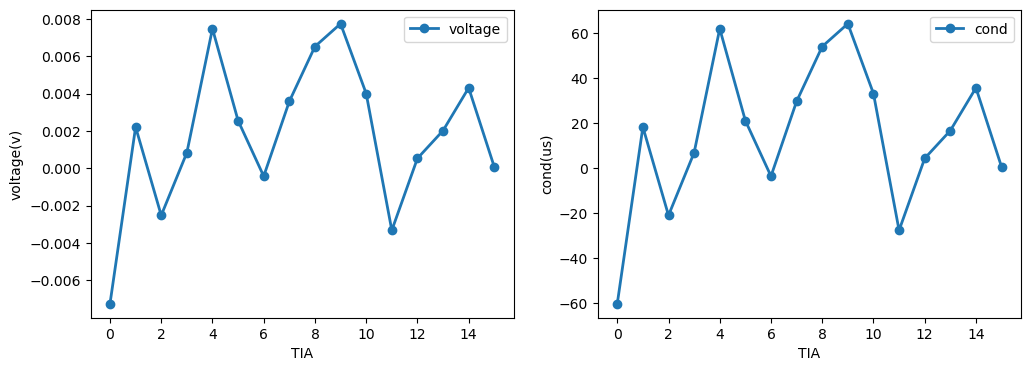

第0次挤出一位


In [ ]:
col_bank = 0

chip.send_cmd(cmd = [CMD(SER_PARA_SEL,command_data=CmdData(1))],mode=1)
chip.set_cim_reset()
chip.set_bank([0],row=True,value=0xFFFF_FFFF)
chip.set_bank([col_bank],row=False,value=0x0000_0003)
col_index = chip.setting.bank_to_num([col_bank])

chip.generate_read_pulse()
voltage = chip.get_tia_out([k for k in range(16)])

print(f"第{0}, {1}位设置为1",voltage)
plot_v_cond(voltage,chip.voltage_to_cond(voltage))

for j in range(32):
    chip.send_cmd(cmd = [CMD(SER_PARA_SEL,command_data=CmdData(0))],mode=1)
    chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_reg_clk))],mode=1)          # cfg_reg_clk
    chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_latch_clk))],mode=1)        # cfg_latch_clk

    chip.generate_read_pulse()
    voltage = chip.get_tia_out([k for k in range(16)])
    print(f"第{j}次挤出一位")
    plot_v_cond(voltage,chip.voltage_to_cond(voltage))
    if j == 31:
        print(is_correct_value(voltage,0.1,tia_num=[]))
    else:
        col1,col2= col_index[min(31,j+1)],col_index[min(31,j+2)]
        tia = [chip.setting.TIA_index_map(col1),chip.setting.TIA_index_map(col2)]
        print(is_correct_value(voltage,0.1,tia_num=tia))